In [18]:
import PcmPy as pcm
import numpy as np
import matplotlib.pyplot as plt
import globals as gl
import os
from vis import plot_theta_lfp, plot_theta_lfp_mean, plot_D_lfp
import warnings

warnings.filterwarnings("ignore")

plt.style.use('default')

In [19]:
path_lfp = os.path.join(gl.baseDir, 'smp2', 'LFPs', gl.pcmDir)
monkey = 'Pert'
cuePre = 0
cueIdx = 20
cuePost = 84
pertIdx = 114

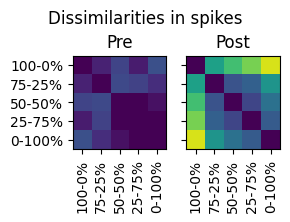

In [20]:
fig, axs = plt.subplots( 1, 2, sharex='col', sharey=True, figsize=(3, 2))

G_obs = np.load(os.path.join(path_lfp, f'G_obs.spike.{monkey}.PMd.aligned.plan.npy'))
ax, h = plot_D_lfp(0, axs, G_obs[:cueIdx].mean(axis=0), list(gl.regressor_mapping.keys())[:5], vmin=0, vmax=.2, sqrt=True)
ax, _ = plot_D_lfp(1, axs, G_obs[cueIdx:cuePost].mean(axis=0), list(gl.regressor_mapping.keys())[:5], vmin=0, vmax=.2, sqrt=True)
axs[0].set_title('Pre')
axs[1].set_title('Post')

fig.suptitle('Dissimilarities in spikes')
fig.tight_layout()

plt.show()

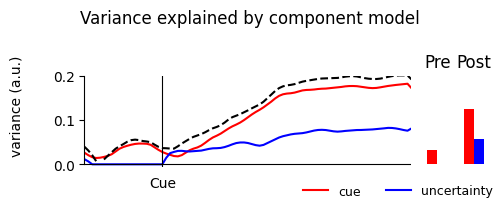

In [21]:
fig, axs = plt.subplots(1,3, sharex='col', sharey=True, figsize=(5, 2), gridspec_kw={'width_ratios': [3, .2, .2]})

theta_in = np.load(os.path.join(path_lfp, f'theta_in.spike.{monkey}.PMd.aligned.plan.npy'))
G_obs = np.load(os.path.join(path_lfp, f'G_obs.spike.{monkey}.PMd.aligned.plan.npy'))
tr = np.sqrt(np.trace(G_obs, axis1=1, axis2=2))
var_expl = np.sqrt(np.exp(theta_in[:, :2]))
ax = plot_theta_lfp(0, axs, var_expl, color=['red', 'blue'])
ax.plot(tr, ls='--', color='k')
ax.spines['left'].set_bounds(0, .2)
ax.axvline(20, color='k', lw=.8)
ax.set_xticks([20])
ax.set_xlim([0, cuePost])
ax.set_ylim([-.005, .2])
ax.set_xticklabels(['Cue'])
ax = plot_theta_lfp_mean(0, 1, axs, var_expl[:cueIdx].mean(axis=0), color=['red', 'blue'])
ax.set_title('Pre')
ax = plot_theta_lfp_mean(0, 2, axs, var_expl[cueIdx:cuePost].mean(axis=0), color=['red', 'blue'])
ax.set_title('Post')

fig.supylabel('variance (a.u.)', fontsize='medium')
fig.legend(['cue', 'uncertainty'], loc='lower right', fontsize=9, frameon=False, ncol=2)
fig.suptitle('Variance explained by component model')

fig.tight_layout()

plt.show()

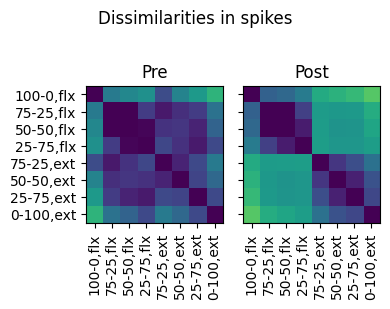

In [22]:
fig, axs = plt.subplots( 1, 2, sharex='col', sharey=True, figsize=(4, 3))

conds = ['100-0,flx', '75-25,flx', '50-50,flx', '25-75,flx', '75-25,ext', '50-50,ext', '25-75,ext', '0-100,ext',]

G_obs = np.load(os.path.join(path_lfp, f'G_obs.spike.{monkey}.PMd.aligned.exec.npy'))
ax, h = plot_D_lfp(0, axs, G_obs[cuePost:pertIdx].mean(axis=0), conds, vmin=0, vmax=.2, sqrt=True)
ax, _ = plot_D_lfp(1, axs, G_obs[pertIdx:].mean(axis=0), conds, vmin=0, vmax=.2, sqrt=True)
axs[0].set_title('Pre')
axs[1].set_title('Post')

fig.suptitle('Dissimilarities in spikes')
fig.tight_layout()

plt.show()

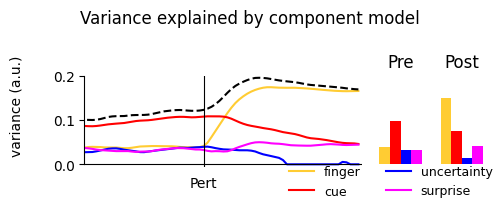

In [23]:
fig, axs = plt.subplots(1,3, sharex='col', sharey=True, figsize=(5, 2), gridspec_kw={'width_ratios': [3, .5, .5]})

theta_in = np.load(os.path.join(path_lfp, f'theta_in.spike.{monkey}.PMd.aligned.exec.npy'))
G_obs = np.load(os.path.join(path_lfp, f'G_obs.spike.{monkey}.PMd.aligned.exec.npy'))
tr = np.sqrt(np.trace(G_obs, axis1=1, axis2=2))
var_expl = np.sqrt(np.exp(theta_in[:, :4]))
ax = plot_theta_lfp(0, axs, var_expl, color=['#FFCC33', 'red', 'blue', 'magenta'])
ax.plot(tr, ls='--', color='k')
ax.spines['left'].set_bounds(0, .2)
ax.axvline(pertIdx, color='k', lw=.8)
ax.set_xticks([pertIdx])
ax.set_xlim([cuePost, var_expl.shape[0]])
ax.set_ylim([-.005, .2])
ax.set_xticklabels(['Pert'])
ax = plot_theta_lfp_mean(0, 1, axs, var_expl[cuePost:pertIdx].mean(axis=0), color=['#FFCC33', 'red', 'blue', 'magenta'])
ax.set_title('Pre')
ax = plot_theta_lfp_mean(0, 2, axs, var_expl[pertIdx:].mean(axis=0), color=['#FFCC33', 'red', 'blue', 'magenta'])
ax.set_title('Post')

fig.supylabel('variance (a.u.)', fontsize='medium')
fig.legend(['finger', 'cue', 'uncertainty', 'surprise'], loc='lower right', fontsize=9, frameon=False, ncol=2)
fig.suptitle('Variance explained by component model')
fig.tight_layout()

plt.show()